open proyecto → bring changes from  GitHub → work → save → git add → git commit → git push

BONDS
# Bonds & Yields Project

## Risk Management - Valuation and Hedging

This project studies the valuation and hedging of bonds using spot rates, forward rates, YTM, duration, DV01 and convexity. The analysis is based on ECB spot yields

Question1
Define a bond and explain how it is issued. Explain the relationship between bonds and interest rates.

A bond is a fixed-income security that represents a loan made by an investor to an issuer. Bonds are typically issued by governments, financial institutions, or corporations, and they generally provide periodic coupon payments together with the repayment of principal at maturity. From the investor’s perspective, bonds are often used to generate relatively stable income and to diversify a portfolio.

A key characteristic of bonds is the inverse relationship between bond prices and market interest rates. When market interest rates increase, the price of existing fixed-rate bonds decreases. This is because the value of a bond depends on the present value of its future cash flows. If newly issued bonds offer higher yields, previously issued bonds with lower coupon rates become less attractive, so their prices must fall to remain competitive in the market.

Question 2 data selection



In [20]:
import pandas as pd

#  Read raw data
raw_path = "../data/raw/ecb_spot_rates_raw.csv"
df_raw = pd.read_csv(raw_path)

print(df_raw.columns.tolist())
print(df_raw.head())

['DATE', 'TIME PERIOD', 'AAA yield curve - 1-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y)', 'AAA yield curve - 1-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M)', 'AAA yield curve - 2-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y)', 'AAA yield curve - 2-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M)', 'AAA yield curve - 3-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y)', 'AAA yield curve - 3-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M)', 'AAA yield curve - 4-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y)', 'AAA yield curve - 4-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M)', 'AAA yield curve - 5-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y)', 'AAA yield curve - 5-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y6M)', 'AAA yield curve - 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M)', 'AAA yield curve - 6-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y)', 'AAA yield curve - 6-year

In [21]:
# Convert date column
df_raw["DATE"] = pd.to_datetime(df_raw["DATE"])

# Choose latest available date
selected_date = df_raw["DATE"].max()


print("Selected date:", selected_date.date())

# Filter the selected row
df_selected = df_raw[df_raw["DATE"] == selected_date].copy()

print("Rows found for selected date:", len(df_selected))
df_selected.head()

Selected date: 2026-03-19
Rows found for selected date: 1


,DATE,TIME PERIOD,AAA yield curve - 1-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y),AAA yield curve - 1-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M),AAA yield curve - 2-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y),AAA yield curve - 2-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M),AAA yield curve - 3-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y),AAA yield curve - 3-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M),AAA yield curve - 4-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y),AAA yield curve - 4-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M),AAA yield curve - 5-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y),AAA yield curve - 5-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y6M),AAA yield curve - 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M),AAA yield curve - 6-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y),AAA yield curve - 6-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y6M)
5504,2026-03-19,19 Mar 2026,2.337735,2.424372,2.468185,2.49495,2.517302,2.540909,2.567863,2.598506,2.632398,2.668812,2.158183,2.706979,2.746191


In [22]:
# 6M to 5Y = 10 periods
SEMIANNUAL_COLS = {
    "SR_6M":   (0.5,  "0.5Y"),
    "SR_1Y":   (1.0,  "1.0Y"),
    "SR_1Y6M": (1.5,  "1.5Y"),
    "SR_2Y":   (2.0,  "2.0Y"),
    "SR_2Y6M": (2.5,  "2.5Y"),
    "SR_3Y":   (3.0,  "3.0Y"),
    "SR_3Y6M": (3.5,  "3.5Y"),
    "SR_4Y":   (4.0,  "4.0Y"),
    "SR_4Y6M": (4.5,  "4.5Y"),
    "SR_5Y":   (5.0,  "5.0Y"),
}

# Match raw columns by their key 
def find_col(df, key):
    matches = [c for c in df.columns if key in c]
    return matches[0]

# Build  DataFrame
records = []
for key, (maturity, label) in SEMIANNUAL_COLS.items():
    col = find_col(df_selected, key)
    records.append({
        "maturity_years": maturity,
        "maturity_label": label,
        "spot_rate":      df_selected[col].iloc[0] / 100,  # decimal form
    })

df_curve = pd.DataFrame(records)
df_curve["date"] = selected_date.date()
df_curve = df_curve[["date", "maturity_label", "maturity_years", "spot_rate"]]

print(df_curve.to_string(index=False))

      date maturity_label  maturity_years  spot_rate
2026-03-19           0.5Y             0.5   0.021582
2026-03-19           1.0Y             1.0   0.023377
2026-03-19           1.5Y             1.5   0.024244
2026-03-19           2.0Y             2.0   0.024682
2026-03-19           2.5Y             2.5   0.024949
2026-03-19           3.0Y             3.0   0.025173
2026-03-19           3.5Y             3.5   0.025409
2026-03-19           4.0Y             4.0   0.025679
2026-03-19           4.5Y             4.5   0.025985
2026-03-19           5.0Y             5.0   0.026324


Question 3:Define a spot rate and its characteristics Explain the method through which spot rates are derived from the market. Plot the
spot yield curve. Interpret from a macroeconomic perspective

Spot rates are the market discount rates applied to zero-coupon bonds for specific maturities. They are also called spot yields and are used to discount a single future cash flow to its present value. In this sense, they reflect the time value of money for a given period without intermediate cash flows. Spot rates differ across maturities, which is why they form a spot yield curve.

Spot rates are derived from market bond prices under a no-arbitrage framework. For zero-coupon bonds, the spot rate can be obtained directly, since the bond pays only one cash flow at maturity. For coupon-bearing bonds, spot rates are estimated through a bootstrapping method. The process starts with the shortest maturities, whose spot rates are identified first, and then progressively moves to longer maturities. At each step, previously derived spot rates are used to discount earlier cash flows, and the remaining unknown rate is solved using the observed bond price. Repeating this procedure across maturities makes it possible to construct the entire spot yield curve.
In this project, we use the ECB’s already estimated AAA spot yield curve, which is constructed from market bond data using the ECB yield curve methodology.

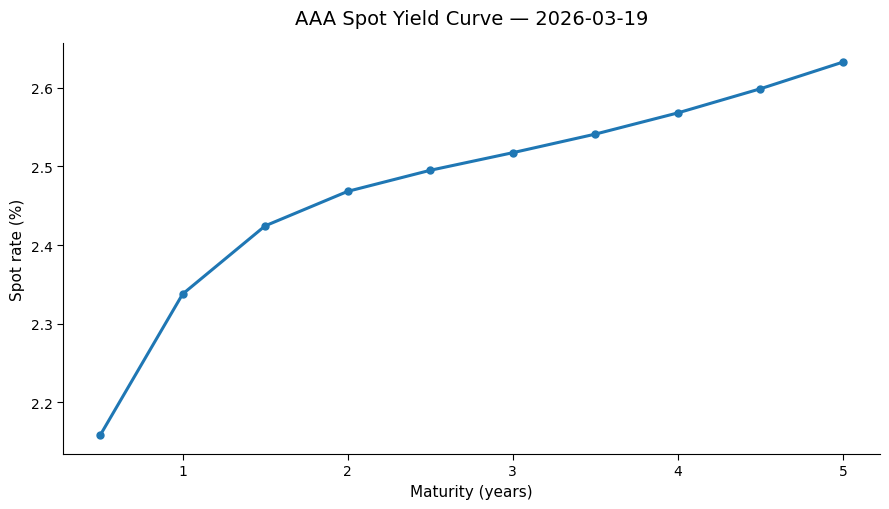

In [23]:
import matplotlib.pyplot as plt


# Convert to percentage only for display
x = df_curve["maturity_years"]
y = df_curve["spot_rate"] * 100

plt.figure(figsize=(9, 5.2))
plt.plot(
    x, y,
    linewidth=2.2,
    marker="o",
    markersize=5
)

plt.title(f"AAA Spot Yield Curve — {selected_date.date()}", fontsize=14, pad=14)
plt.xlabel("Maturity (years)", fontsize=11)
plt.ylabel("Spot rate (%)", fontsize=11)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)
ax.grid(False)

plt.tight_layout()
plt.show()

The shape of the yield curve reflects the relationship between short-, medium-, and long-term interest rates. It can provide useful information about market expectations and the general economic outlook. In this case, the AAA spot yield curve is upward sloping over the 0.5 to 5-year horizon. From a macroeconomic perspective, this suggests that markets expect future short-term interest rates to remain relatively high or to increase moderately compared with current short-term rates. This is consistent with a normal yield curve and may reflect expectations of resilient economic activity, stable inflation dynamics, and a positive term premium on longer maturities.

The curve is steeper at the short end and then becomes more gradual after around two years. This may indicate that the main monetary policy adjustment is expected to occur in the near to medium term, while longer-term expectations remain more anchored. In other words, short-term monetary policy expectations appear to be more sensitive to current macroeconomic conditions, whereas longer-term inflation and growth expectations seem more stable.

Question4/ Using two non-consecutive semi-annual spot yields (for example, n1 and n3, where “n” defines the 10 semi-annual spot yields
you have selected), perform a linear interpolation to estimate the value of another semi-annual spot yield (for example, n2).
Compare the estimated value of the semi-annual spot yield to the observed one. Interpret.

The linear interpolation formula is:


- $T_L$ be the lower maturity,
- $T_U$ be the upper maturity,
- $T^*$ be the intermediate maturity to be estimated,
- $s(T_L)$ be the observed spot yield at the lower maturity,
- $s(T_U)$ be the observed spot yield at the upper maturity.

The interpolated spot yield is given by:

$$
\tilde{s}(T^*) = s(T_L) + \frac{T^* - T_L}{T_U - T_L}\left[s(T_U) - s(T_L)\right]
$$

In [24]:
# Lower, target, and upper maturities
T_L = 1.0
T_star = 1.5
T_U = 2.0

# Observed spot yields
s_L = df_curve.loc[df_curve["maturity_years"] == T_L, "spot_rate"].iloc[0]
s_star_obs = df_curve.loc[df_curve["maturity_years"] == T_star, "spot_rate"].iloc[0]
s_U = df_curve.loc[df_curve["maturity_years"] == T_U, "spot_rate"].iloc[0]

print("Lower maturity:", T_L, "Observed spot rate:", s_L)
print("Target maturity:", T_star, "Observed spot rate:", s_star_obs)
print("Upper maturity:", T_U, "Observed spot rate:", s_U)

Lower maturity: 1.0 Observed spot rate: 0.023377349999999998
Target maturity: 1.5 Observed spot rate: 0.02424372
Upper maturity: 2.0 Observed spot rate: 0.02468185


In [25]:
# Linear interpolation
s_star_interp = s_L + ((T_star - T_L) / (T_U - T_L)) * (s_U - s_L)

print("Interpolated spot rate at", T_star, "years:", s_star_interp)

Interpolated spot rate at 1.5 years: 0.024029599999999998


In [26]:
# Difference between observed and interpolated values
difference = s_star_obs - s_star_interp
difference_bps = difference * 10000  # convert to basis points

print("Observed spot rate:     ", round(s_star_obs, 6))
print("Interpolated spot rate: ", round(s_star_interp, 6))
print("Difference:             ", round(difference,6))
print("Difference (bps):       ", round(difference_bps,2))

Observed spot rate:      0.024244
Interpolated spot rate:  0.02403
Difference:              0.000214
Difference (bps):        2.14


The interpolated 1.5-year spot yield is slightly below the observed one. The gap is equal to 0.000214(2.14 basis points). This indicates that the actual curve is not exactly linear between the 1-year and 2-year maturities, but the difference is small enough to conclude that linear interpolation remains a good approximation over this interval.

In [27]:
# Function to get spot rate by maturity
def get_rate(df, maturity):
    return df.loc[df["maturity_years"] == maturity, "spot_rate"].values[0]

# Define maturities
x1 = 1.0
xi = 1.5
x2 = 2.0

# Extract rates directly from df_curve 
y1 = get_rate(df_curve, x1)
y2 = get_rate(df_curve, x2)
y_obs = get_rate(df_curve, xi)

# Linear interpolation
y_interp = y1 + (y2 - y1) * ((xi - x1) / (x2 - x1))

# Errors
error = y_obs - y_interp
error_bps = error * 10000  # decimal to bps

print(f"Interpolated rate: {y_interp:.6f}")
print(f"Observed rate:     {y_obs:.6f}")
print(f"Difference:        {error:.6f}")
print(f"Difference (bps):  {error_bps:.2f}")

Interpolated rate: 0.024030
Observed rate:     0.024244
Difference:        0.000214
Difference (bps):  2.14


Question 5

In [28]:
# Question 5: Calculating price of STRIPS

PAR_VALUE = 100
m = 2  # semi-annual compounding

df_strips = df_curve.copy()

df_strips["strip_price"] = PAR_VALUE / ((1 + df_strips["spot_rate"] / m) ** (m * df_strips["maturity_years"]))

# optional display columns
df_strips["spot_rate_pct"] = df_strips["spot_rate"] * 100

df_strips = df_strips[["date", "maturity_label", "maturity_years", "spot_rate_pct", "strip_price"]]

print(df_strips.to_string(index=False))

      date maturity_label  maturity_years  spot_rate_pct  strip_price
2026-03-19           0.5Y             0.5       2.158183    98.932429
2026-03-19           1.0Y             1.0       2.337735    97.702623
2026-03-19           1.5Y             1.5       2.424372    96.449856
2026-03-19           2.0Y             2.0       2.468185    95.212249
2026-03-19           2.5Y             2.5       2.494950    93.989425
2026-03-19           3.0Y             3.0       2.517302    92.769919
2026-03-19           3.5Y             3.5       2.540909    91.542061
2026-03-19           4.0Y             4.0       2.567863    90.297472
2026-03-19           4.5Y             4.5       2.598506    89.031525
2026-03-19           5.0Y             5.0       2.632398    87.742725


# STRIPS pricing from spot rates

To compute the price of each STRIP, we reverse the standard formula. A STRIP is a zero-coupon bond, so its price is given by discounting its face value using the corresponding spot rate:

$$P = \frac{FV}{(1 + y)^T}$$

Where:

| Symbol | Definition |
|--------|------------|
| $P$ | Price of the STRIP |
| $FV$ | Face value |
| $y$ | Spot rate |
| $T$ | Maturity in years |


## Interpretation

All computed STRIP prices are below par (100). This is expected because all spot rates are positive. Since future cash flows are discounted at positive interest rates, their present value must be lower than the face value.

Additionally, as maturity increases, STRIP prices decrease further. This reflects the time value of money: the longer the time to maturity, the greater the discounting effect.

Question 6

Forward Rate and Forward Yield Curve

A forward rate represents the interest rate of a future period.

**The main characteristics of a forward rate are:**

- the forward rate discounts cash flows by one period;
- assuming one period is 6 months, the forward rate discounts cash flows from one future date back to the previous date;
- investors are indifferent between an investment with a spot rate or with a forward rate, as the return is the same;
- the forward yield curve is the graph that shows the relationship between forward rates and maturity.

## Deriving forward rates from spot rates

Forward rates are derived from spot rates. To deduce a forward rate $f(t)$, the following equation is applied:

$$\left(1+\frac{s_t}{m}\right)^l = \left(1+\frac{s_{t-1}}{m}\right)^{l-1} \cdot \left(1+\frac{f(t)}{m}\right)$$

**Where:**

| Symbol | Definition |
|--------|------------|
| $s_t$ | Spot rate at time $t$ |
| $s_{t-1}$ | Spot rate at time $t-1$ |
| $l$ | Number of periods |
| $m$ | Number of periods per year |
| $f(t)$ | Forward rate corresponding to the spot rate $s_t$ |


## Application: semi-annual periods

In our case, we use semi-annual periods, so:

- One period = 6 months
- $m = 2$

Therefore, for each maturity, the forward rate is derived from two consecutive spot rates.

In [29]:
m = 2  # number of periods per year

df_forward = df_curve.copy().sort_values("maturity_years").reset_index(drop=True)

forward_rates = []

for i in range(len(df_forward)):
    t = df_forward.loc[i, "maturity_years"]
    s_t = df_forward.loc[i, "spot_rate"]
    l = int(t * m)  # number of periods

    if i == 0:
        f_t = s_t
    else:
        s_t_minus_1 = df_forward.loc[i - 1, "spot_rate"]

        f_t = m * (
            ((1 + s_t / m) ** l) /
            ((1 + s_t_minus_1 / m) ** (l - 1))
            - 1
        )

    forward_rates.append(f_t)

df_forward["forward_rate"] = forward_rates
df_forward["spot_rate_pct"] = df_forward["spot_rate"] * 100
df_forward["forward_rate_pct"] = df_forward["forward_rate"] * 100

# to see intervals 
df_forward["forward_start"] = df_forward["maturity_years"] - 0.5
df_forward["forward_end"] = df_forward["maturity_years"]

# first forward rate corresponds to the first semi-annual period
df_forward.loc[0, "forward_start"] = 0.0

print(
    df_forward[
        [
            "maturity_label",
            "forward_start",
            "forward_end",
            "spot_rate_pct",
            "forward_rate_pct"
        ]
    ].round(4).to_string(index=False)
)

maturity_label  forward_start  forward_end  spot_rate_pct  forward_rate_pct
          0.5Y            0.0          0.5         2.1582            2.1582
          1.0Y            0.5          1.0         2.3377            2.5174
          1.5Y            1.0          1.5         2.4244            2.5978
          2.0Y            1.5          2.0         2.4682            2.5997
          2.5Y            2.0          2.5         2.4949            2.6020
          3.0Y            2.5          3.0         2.5173            2.6291
          3.5Y            3.0          3.5         2.5409            2.6826
          4.0Y            3.5          4.0         2.5679            2.7566
          4.5Y            4.0          4.5         2.5985            2.8438
          5.0Y            4.5          5.0         2.6324            2.9377


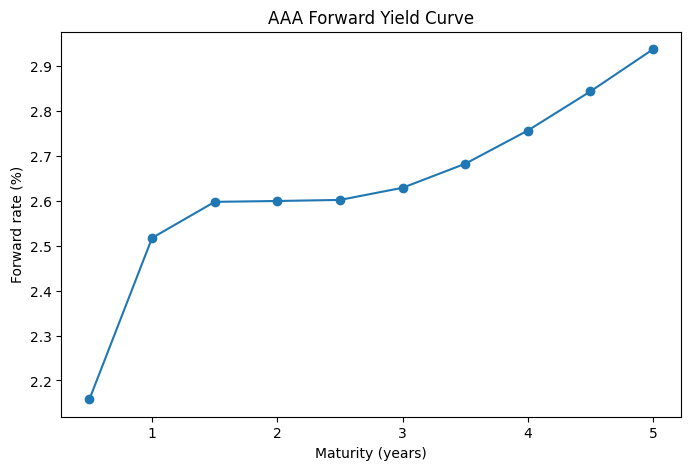

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(df_forward["maturity_years"], df_forward["forward_rate_pct"], marker="o")

plt.title("AAA Forward Yield Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Forward rate (%)")

plt.show()

The spot curve shows zero-coupon yields from today to each maturity. By contrast, each forward rate represents the implied interest rate between two consecutive semi-annual maturities. In this project, for simplicity, each forward rate is plotted at its ending maturity.

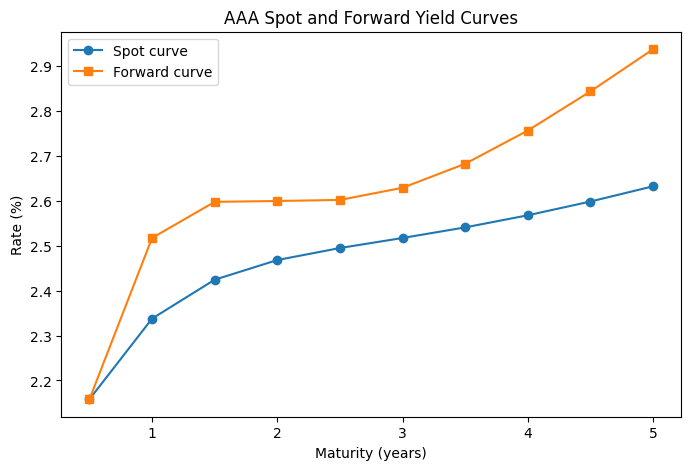

In [31]:
plt.figure(figsize=(8,5))

plt.plot(df_curve["maturity_years"], df_curve["spot_rate"] * 100, marker="o", label="Spot curve")
plt.plot(df_forward["maturity_years"], df_forward["forward_rate_pct"], marker="s", label="Forward curve")

plt.title("AAA Spot and Forward Yield Curves")
plt.xlabel("Maturity (years)")
plt.ylabel("Rate (%)")

plt.grid(False)
plt.legend()
plt.show()

Question 7

In [32]:
# Variables

FV = 1000
r = 0.02
freq = 2 # paid semi-annually
coupon = FV * r / freq

n_periods = 3 * freq

times = []
for i in range(1, n_periods + 1):
    times.append(i / freq)

cash_flows = []
for i in range(1, n_periods + 1):
    if i < n_periods:
        cash_flows.append(coupon)
    else:
        cash_flows.append(coupon + FV)

print(times)
print(cash_flows)

# Spot rates for 02/01/2025, at semi-annual maturities from 6 months to 3 years

spot_rates = [
    0.02425927,
    0.02191738,
    0.02066626,
    0.02007620,
    0.01988808,
    0.01994412
]

# Calcualte price using spot rates

price_spot = 0

for cf, t, s in zip(cash_flows, times, spot_rates):
    pv = cf / (1 + s / freq) ** (t * freq)
    price_spot += pv

print("Bond price using spot rates:", price_spot)

# Derive forward rates from spot rates

forward_rates = []

for i in range(len(spot_rates)):
    t = times[i]
    s_t = spot_rates[i]
    l = int(t * freq)   # number of semi-annual periods

    if i == 0:
        f_t = s_t
    else:
        s_prev = spot_rates[i - 1]

        f_t = freq * (
            ((1 + s_t / freq) ** l) /
            ((1 + s_prev / freq) ** (l - 1))
            - 1
        )

    forward_rates.append(f_t)

print("Forward rates:", forward_rates)

price_forward = 0

for i in range(len(cash_flows)):
    discount_factor = 1

    for j in range(i + 1):
        discount_factor *= (1 + forward_rates[j] / freq)

    pv = cash_flows[i] / discount_factor
    price_forward += pv

print("Bond price using forward rates:", price_forward)

[0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
[10.0, 10.0, 10.0, 10.0, 10.0, 1010.0]
Bond price using spot rates: 1000.1101122901654
Forward rates: [0.02425927, 0.019578199360828386, 0.01816634202128231, 0.018307053628467962, 0.019135775170811442, 0.02022434332256262]
Bond price using forward rates: 1000.1101122901654


## Observation

The price of a bond using spot rates and forward rates are the same. This is because forward rates are implied by the spot-rate curve, so both approaches use the same information from the term structure of interest rates. The spot-rate method discounts each cash flow directly to today, while the forward-rate method discounts the cash flows period by period. 

Question 8

### Dirty and clean price

Considering the fact that the bond is purchased 50 days after issuance, the first remaining cash flow is discounted over a fractional coupon period.  In this case, The dirty price is  computed as the present value of the remaining cash flows using spot rates

$$
P_{\text{dirty}}=\sum_{i=1}^{n}\frac{CF_i}{\left(1+\frac{s_i}{m}\right)^{\,i-1+w}}
$$

where $CF_i$ is the cash flow at period $i$, $s_i$ is the corresponding spot rate, $m$ is the coupon frequency, and $w$ is the fraction of the coupon period remaining until the next payment date:

$$
w=\frac{\text{days until next coupon}}{\text{days in coupon period}}
$$

The accrued (cumulated) interest is calculated as:

$$
{\text{Accrued interest}}=C\times\frac{\text{days accrued}}{\text{days in coupon period}}
$$

The clean price is:

$$
P_{\text{clean}} = P_{\text{dirty}} - {\text{Accrued interest}}
$$

Thus, the dirty price includes in its pricing the  accrued interest, while the clean price excludes it.

In [33]:
#  50 days after issuance

days_accrued = 50
days_in_coupon_period = 180   #semi-annual 30/360
days_until_next_coupon = days_in_coupon_period - days_accrued # remaining days

# Fraction of the coupon period 
w = days_until_next_coupon / days_in_coupon_period

print("w =", round(w, 6))

# Dirty price
dirty_price = 0

for i in range(n_periods):
    cf = cash_flows[i]
    s = spot_rates[i]

    if i < n_periods - 1:
        pv = cf / (1 + s / freq) ** (i + w)
    else:
        pv = (coupon + FV) / (1 + s / freq) ** (i + w)

    dirty_price += pv

print("Dirty price:", round(dirty_price, 4))

# Accrued interest calculation (coupon part already 'gained' by the holder)
accrued_interest = coupon * (days_accrued / days_in_coupon_period)

print("Accrued interest:", round(accrued_interest, 4))

# Clean price
clean_price = dirty_price - accrued_interest

print("Clean price:", round(clean_price, 4))

w = 0.722222
Dirty price: 1002.8801
Accrued interest: 2.7778
Clean price: 1000.1023


The dirty price is equal to 1002.8801. Since the bond is purchased between dates, the buyer must also compensate the seller for the accrued interest.This accrued interest is 2.7778.

The clean price is 1000.102 and it is very close to par. The fact that the clean price is slightly above par indicates a small premium, while the difference between dirty and clean price  reflects the accrued coupon earned by the seller before the transaction date.

Question 9

In [34]:
# Question 9
# 

def bond_price_from_ytm(y, cash_flows, freq):
    price = 0
    for i, cf in enumerate(cash_flows, start=1):
        price += cf / (1 + y / freq) ** i
    return price

def ytm_bisection(target_price, cash_flows, freq, low=0.0, high=0.10, tol=1e-10, max_iter=1000):
    for _ in range(max_iter):
        mid = (low + high) / 2
        price_mid = bond_price_from_ytm(mid, cash_flows, freq)

        if abs(price_mid - target_price) < tol:
            return mid

        if price_mid > target_price:
            low = mid
        else:
            high = mid

    return mid

ytm = ytm_bisection(price_spot, cash_flows, freq)

print(" Bond price:", round(price_spot, 4))
print("Estimated YTM:", round(ytm, 6))
print("Estimated YTM (%):", round(ytm * 100, 4))

 Bond price: 1000.1101
Estimated YTM: 0.019962
Estimated YTM (%): 1.9962


Question 10

“dollar value of an 01”

In [35]:
# using previously defined function to find the bond price
# YTM Reduction by 5 basis points (0.05%)
P0=price_spot
dy_5bp = -0.0005   # -0.05%

P_down_5bp = bond_price_from_ytm(ytm + dy_5bp, cash_flows, freq)
price_change_5bp = P_down_5bp - P0

DV01 = price_change_5bp / 5

print("Initial bond price:", round(P0, 4))
print("Bond price after -5 bps:", round(P_down_5bp, 4))
print("Price change for -5 bps:", round(price_change_5bp, 4))
print("DV01:", round(DV01, 4))

Initial bond price: 1000.1101
Bond price after -5 bps: 1001.5604
Price change for -5 bps: 1.4503
DV01: 0.2901


INTERPRET


In [36]:
# b) Duration and convexity using increase-decrease of 0.55%

dy = 0.0055   # 0.55%

P_minus = bond_price_from_ytm(ytm - dy, cash_flows, freq)
P_plus  = bond_price_from_ytm(ytm + dy, cash_flows, freq)

duration = (P_minus - P_plus) / (2 * P0 * dy)
convexity = (P_minus + P_plus - 2 * P0) / (P0 * dy**2)

print("Price after change decreased in YTM:", round(P_minus, 4))
print("Price after change increased in YTM:", round(P_plus, 4))
print("Duration:", round(duration, 6))
print("Convexity:", round(convexity, 6))

Price after change decreased in YTM: 1016.2015
Price after change increased in YTM: 984.32
Duration: 2.897996
Convexity: 9.959243


interpret

In [37]:
# Price change for increase-decrease 1.8% using duration and convexity

dy_large = 0.018   # 1.8%

# Increase in YTM
deltaP_over_P_up = -duration * dy_large + 0.5 * convexity * (dy_large ** 2)
deltaP_up = P0 * deltaP_over_P_up
P_approx_up = P0 + deltaP_up

# Decrease in YTM
deltaP_over_P_down = -duration * (-dy_large) + 0.5 * convexity * (dy_large ** 2)
deltaP_down = P0 * deltaP_over_P_down
P_approx_down = P0 + deltaP_down

print(" % Price change for +1.8% YTM :", round(deltaP_over_P_up * 100, 4), "%")
print(" Price change for +1.8% YTM :", round(deltaP_up, 4))
print(" Bond price after +1.8% YTM :", round(P_approx_up, 4))

print()

print(" % Price change for -1.8% YTM :", round(deltaP_over_P_down * 100, 4), "%")
print(" Price change for -1.8% YTM :", round(deltaP_down, 4))
print(" Bond price after -1.8% YTM :", round(P_approx_down, 4))

 % Price change for +1.8% YTM : -5.0551 %
 Price change for +1.8% YTM : -50.5561
 Bond price after +1.8% YTM : 949.554

 % Price change for -1.8% YTM : 5.3777 %
 Price change for -1.8% YTM : 53.7832
 Bond price after -1.8% YTM : 1053.8934


Question 11

In [ ]:
# Bond from Q7a 
DV01_OP     = DV01        # 0.2901
D_OP        = duration    # 2.90
Cx_OP       = convexity   # 9.96
V_OP        = 7_300_000   # $7.3M position

# Two hedging bonds (chosen)
# Bond 1: 5-year government bond
# Bond 2: 10-year government bond
DV01_HI1, D_HI1, Cx_HI1 = 0.045, 4.5, 24.0
DV01_HI2, D_HI2, Cx_HI2 = 0.085, 8.2, 78.0


# a) DV01 hedge using Bond 1

HR_dv01      = DV01_OP / DV01_HI1
fv_hedge_dv01 = V_OP * HR_dv01

print(f"Hedge ratio : {round(HR_dv01, 4)}")
print(f"Short ${fv_hedge_dv01:,.0f} face value of Bond 1")

Hedge ratio : 6.4458
Short $47,054,312 face value of Bond 1


In [39]:
# b) Duration hedge using Bond 2

V_HI_dur = -(D_OP * V_OP) / D_HI2

print(f"Short ${abs(V_HI_dur):,.0f} of Bond 2")

Short $2,579,923 of Bond 2


In [43]:
# c) Duration + Convexity hedge using Bond 1 and Bond 2

numerator   = V_OP * Cx_OP - (V_OP * D_OP * Cx_HI1) / D_HI1
denominator = Cx_HI2 - (D_HI2 * Cx_HI1) / D_HI1

V_HI2_dc = numerator / denominator
V_HI1_dc = (V_OP * D_OP - V_HI2_dc * D_HI2) / D_HI1

print(f"Bond 1 position: ${V_HI1_dc:,.0f}")
print(f"Bond 2 position: ${V_HI2_dc:,.0f}")

# Verification
print("\nVerification")
print(f"Duration  | target: {round(V_OP*D_OP,1):>12} | achieved: {round(V_HI1_dc*D_HI1 + V_HI2_dc*D_HI2,1):>12}")
print(f"Convexity | target: {round(V_OP*Cx_OP,1):>12} | achieved: {round(V_HI1_dc*Cx_HI1 + V_HI2_dc*Cx_HI2,1):>12}")

Bond 1 position: $6,835,009
Bond 2 position: $-1,170,997

Verification
Duration  | target:   21155367.9 | achieved:   21155367.9
Convexity | target:   72702475.7 | achieved:   72702475.7
